# 🌿 InnerFlow

> **"몸과 마음의 흐름을 발견하고, 나만의 웰니스 루틴을 만들어가는 AI Wellness Companion"**

## 프로젝트 목적

InnerFlow의 목표는 단순히 운동을 추천하는 것이 아니라,
사용자가 **스스로를 돌보는 습관(Self-care Habit)** 을 만들어갈 수 있도록 돕는 것입니다.

매일 짧은 시간이라도 자신의 감정을 돌아보고,
현재에 집중하며,
자신에게 맞는 웰니스 활동을 실천하는 과정을 통해
지속 가능한 웰니스 루틴을 형성하는 것을 목표로 합니다.

또한 요가와 마음챙김에 대한 학습 콘텐츠를 함께 제공하여
사용자가 웰니스를 단순한 실천이 아닌 '배움'의 과정으로 경험할 수 있도록 합니다.

In [2]:
from typing import Literal
from langgraph.graph import MessagesState

class InnerFlowState(MessagesState):
    # 라우팅
    mode: Literal["wellness", "learning"]

    # morning / evening
    period: Literal["morning", "evening"]

    # 사용자 입력
    user_input: str

    # 감정 분석 결과
    emotion: str

    # 마음챙김 문구
    mindfulness_message: str

    # 오늘의 확언 또는 감사일기
    journal: str

    # 추천 요가
    recommended_poses: list[str]

    # 사용자가 선택한 자세
    selected_pose: str

    # 오늘 배운 내용
    learning_note: str

/Users/jin/Desktop/nomad_coder/AI_agent/InnerFlowAgent/.venv/lib/python3.12/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

# =========================
# Nodes
# =========================

def router(state: InnerFlowState):
    return {}


def wellness(state: InnerFlowState):
    return {}


def learning(state: InnerFlowState):
    return {}


# =========================
# Router
# =========================

def route(state: InnerFlowState):
    return state["mode"]


# =========================
# Graph
# =========================

builder = StateGraph(InnerFlowState)

builder.add_node("router", router)
builder.add_node("wellness", wellness)
builder.add_node("learning", learning)

builder.add_edge(START, "router")

builder.add_conditional_edges(
    "router",
    route,
    {
        "wellness": "wellness",
        "learning": "learning",
    },
)

builder.add_edge("wellness", END)
builder.add_edge("learning", END)

graph = builder.compile()

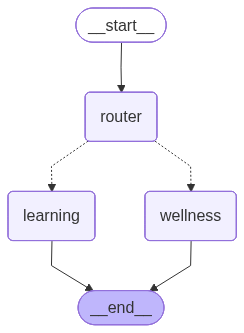

In [4]:
graph

## 07.15 수정

In [12]:
from typing_extensions import TypedDict
from typing import Literal
from langgraph.graph import MessagesState
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain.chat_models import init_chat_model
from pydantic import BaseModel
from operator import add

llm = init_chat_model("openai:gpt-4o")


In [13]:
class ActivityGuidance(BaseModel):
    intention: str

    tone: Literal[
        "energizing",
        "grounding",
        "calming",
        "restorative",
    ]

    focus: Literal[
        "body",
        "breath",
        "mind",
        "gratitude",
        "self_compassion",
    ]


class ActivityPlan(BaseModel):
    activity: Literal[
        "yoga",
        "breathing",
        "meditation",
    ]

    # 사용자에게 보여줄 추천 이유
    reason: str

    # Activity Agent에게 전달할 내부 정보
    guidance: ActivityGuidance

class InnerFlowState(MessagesState):
    # Input
    user_name: str
    session_type: Literal["morning", "pause", "evening"]
    current_feeling: str

    # Flow Guide
    awareness: str
    reflection_message: str
    mini_practice: str

    activity_plans: list[ActivityPlan]

    # MVP에서는 GPT가 결정
    selected_activity: Literal[
        "yoga",
        "breathing",
        "meditation"
    ]

    # Activity Output
    activity_result: str

class FlowGuideOutput(BaseModel):

    awareness: str

    reflection_message: str

    mini_practice: str

    activity_plans: list[ActivityPlan]

    selected_activity: Literal[
        "yoga",
        "breathing",
        "meditation"
    ]

class ActivityOutput(BaseModel):
    activity_result: str

In [17]:


def flow_guide_agent(state: InnerFlowState):
    structured_llm = llm.with_structured_output(FlowGuideOutput)
    response = structured_llm.invoke(
        f"""
    너는 InnerFlow의 Flow Guide Agent이다.

    역할
    - 사용자의 현재 상태를 알아차리도록 돕는다.
    - 현재 시점(morning/pause/evening)을 고려한다.
    - 감정을 해결하려 하지 않는다.
    - 짧은 마음챙김 경험을 제공한다.
    - 요가, 호흡, 명상을 모두 추천하지만,
    현재 상태에 가장 적합한 활동 하나를 selected_activity로 선택한다.

    사용자 정보

    이름
    {state["user_name"]}

    현재 시점
    {state["session_type"]}

    현재 상태
    {state["current_feeling"]}

    activity_plans에는

    - yoga
    - breathing
    - meditation

    세 가지 모두 작성한다.

    각 activity에는

    - reason
    - guidance
        - intention
        - tone
        - focus

    를 포함한다.

    selected_activity에는
    가장 추천하는 활동 하나를 선택한다.

    **중요**
    절대로 상담사처럼 말하지 않는다.
    절대로 AI처럼 분석하지 않는다.

    친한 요가 선생님처럼
    따뜻하고 자연스럽게 이야기한다.

    "당신은 ~~입니다."
    같은 표현은 사용하지 않는다.

    "오늘 정말 애쓰셨네요."
    "많이 지치셨겠어요."

    같이 사람에게 이야기하듯 작성한다.

    반드시 아래 형식에 맞게 응답한다.

    awareness:
    현재 상태를 따뜻하게 알아차리는 문장 (2~3문장)

    reflection_message:
    현재 사용자에게 전하고 싶은 짧은 성찰 문장 (1~2문장)

    mini_practice:
    10~20초 정도 수행할 수 있는 아주 짧은 마음챙김 활동

    activity_plans:
    요가, 호흡, 명상을 모두 작성

    selected_activity:
    세 활동 중 하나만 선택
    """
    )

    return {
        "awareness": response.awareness,
        "reflection_message": response.reflection_message,
        "mini_practice": response.mini_practice,
        "activity_plans": response.activity_plans,
        "selected_activity": response.selected_activity,
    }

def activity_router(state:InnerFlowState):
    return state["selected_activity"]


def yoga_agent(state: InnerFlowState):

    plan = next(
        plan
        for plan in state["activity_plans"]
        if plan.activity == "yoga"
    )

    response = llm.invoke(
        f"""
    너는 요가 전문가이다.

    Flow Guide가 이미 사용자의 상태를 분석했다.
    너는 다시 감정을 분석하지 않는다.

    이번 요가의 목적

    {plan.guidance.intention}

    분위기

    {plan.guidance.tone}

    집중할 대상

    {plan.guidance.focus}

    추천 이유

    {plan.reason}

    위 내용을 바탕으로

    1. 시작 안내
    2. 초보자도 가능한 요가 자세 3가지
    3. 각 자세를 추천한 이유
    4. 마무리 한 문장

    을 작성해줘.
    """
    )

    return {
        "activity_result": response.content
    }

def breathing_agent(state: InnerFlowState):

    plan = next(
        plan
        for plan in state["activity_plans"]
        if plan.activity == "breathing"
    )

    response = llm.invoke(
        f"""
        너는 호흡 코치이다.

        Flow Guide가 이미 현재 상태를 분석했다.

        이번 호흡의 목적

        {plan.guidance.intention}

        분위기

        {plan.guidance.tone}

        집중할 대상

        {plan.guidance.focus}

        추천 이유

        {plan.reason}

        약 1분 정도 진행할 수 있는
        호흡 가이드를 작성해줘.

        TTS로 읽기 좋은 자연스러운 문장으로 작성해줘.
        """
    )

    return {
        "activity_result": response.content
    }

def meditation_agent(state: InnerFlowState):

    plan = next(
        plan
        for plan in state["activity_plans"]
        if plan.activity == "meditation"
    )

    response = llm.invoke(
        f"""
        너는 명상 가이드이다.

        Flow Guide가 이미 사용자의 상태를 분석했다.

        이번 명상의 목적

        {plan.guidance.intention}

        분위기

        {plan.guidance.tone}

        집중할 대상

        {plan.guidance.focus}

        추천 이유

        {plan.reason}

        약 2분 정도 진행할 수 있는
        초보자용 명상 스크립트를 작성해줘.

        차분하고 따뜻한 말투를 사용해줘.
        """
    )

    return {
        "activity_result": response.content
    }

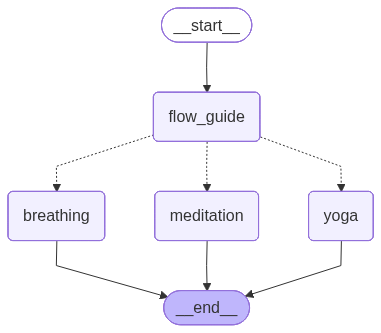

In [18]:
graph_builder = StateGraph(InnerFlowState)

graph_builder.add_node("flow_guide", flow_guide_agent)
graph_builder.add_node("yoga", yoga_agent)
graph_builder.add_node("breathing", breathing_agent)
graph_builder.add_node("meditation", meditation_agent)

graph_builder.add_edge(START, "flow_guide")
graph_builder.add_conditional_edges(
    "flow_guide",
    activity_router,
    {
        "yoga" : "yoga",
        "breathing" : "breathing",
        "meditation" : "meditation"
    }
)
graph_builder.add_edge("yoga",END)
graph_builder.add_edge("breathing",END)
graph_builder.add_edge("meditation",END)

graph = graph_builder.compile()

graph

In [19]:
result = graph.invoke(
    {
        "user_name": "진민",
        "session_type": "evening",
        "current_feeling": "오늘 정말 피곤했고 회사에서 계속 스트레스 받음"
    }
)

print(result)

/Users/jin/Desktop/nomad_coder/AI_agent/InnerFlowAgent/.venv/lib/python3.12/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=FlowGuideOutput(awareness...elected_activity='yoga'), input_type=FlowGuideOutput])
  return self.__pydantic_serializer__.to_python(


{'messages': [], 'user_name': '진민', 'session_type': 'evening', 'current_feeling': '오늘 정말 피곤했고 회사에서 계속 스트레스 받음', 'awareness': '오늘 정말 애쓰셨네요. 회사에서 많은 스트레스를 받으셨군요, 많이 지치셨겠어요. 하루의 끝에서 잠시 숨을 고르기 위해 필요한 시간을 보내보는 게 좋을 것 같아요.', 'reflection_message': '지금은 스스로에게 편안함을 주는 시간을 준비해보는 것이 좋겠어요. 이 순간이 지나가는 동안, 마음의 안식을 찾을 수 있을 거예요.', 'mini_practice': '살짝 눈을 감고, 깊은 호흡 한 번 해볼까요? 숨을 천천히 들이마셨다 내쉬며, 오늘 하루를 놓아보세요.', 'activity_plans': [ActivityPlan(activity='yoga', reason='몸과 마음의 긴장을 풀어주고, 하루의 스트레스를 해소하는 데 도움을 줄 수 있어요.', guidance=ActivityGuidance(intention='긴장을 완화하고 편안함을 찾기 위해', tone='restorative', focus='body')), ActivityPlan(activity='breathing', reason='심신의 평화를 찾고, 깊은 호흡으로 차분한 상태를 만들어 줄 거예요.', guidance=ActivityGuidance(intention='마음의 평화와 안정감을 찾기 위해', tone='calming', focus='breath')), ActivityPlan(activity='meditation', reason='하루의 끝자락에서 내면의 고요함과 연결됨을 느끼게 해 줄 거예요.', guidance=ActivityGuidance(intention='평화로운 저녁을 마무리하기 위해', tone='calming', focus='mind'))], 'selected_activity': 'yoga', 'activity_result': '### 시작